📊 Model Performance Comparison:

                     Model  Accuracy  Precision  Recall  F1-Score
0            Random Forest       1.0        1.0     1.0  1.000000
1  Optimized Random Forest       0.2        0.1     0.2  0.133333


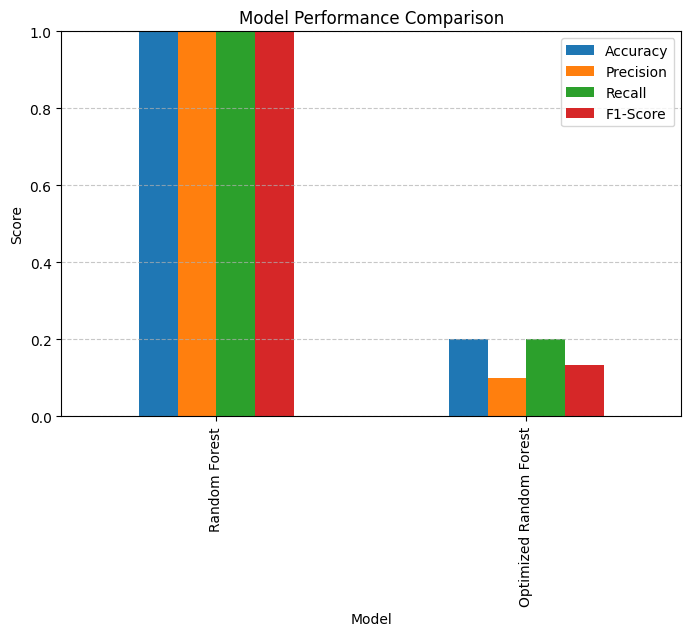


📈 Classification Report (Random Forest):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10


📉 Classification Report (Optimized Random Forest):
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.00      0.00      0.00         3
           2       0.00      0.00      0.00         0
           3       0.00      0.00      0.00         1
           4       0.33      0.67      0.44         3
           5       0.00      0.00      0.00         1

    accuracy                       

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [2]:
# --- Enhanced Model Comparison (Member 2) ---

import joblib
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt

# Load models
rf_model = joblib.load('../models/random_forest_model.joblib')
optimized_rf_model = joblib.load('../models/optimized_random_forest.joblib')

# Predict
rf_pred = rf_model.predict(X_test)
opt_pred = optimized_rf_model.predict(X_test)

# Evaluate both models
metrics = {
    "Model": ["Random Forest", "Optimized Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, opt_pred)
    ],
    "Precision": [
        precision_score(y_test, rf_pred, average='weighted', zero_division=0),
        precision_score(y_test, opt_pred, average='weighted', zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, rf_pred, average='weighted', zero_division=0),
        recall_score(y_test, opt_pred, average='weighted', zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, rf_pred, average='weighted', zero_division=0),
        f1_score(y_test, opt_pred, average='weighted', zero_division=0)
    ]
}

# Convert to DataFrame
df_results = pd.DataFrame(metrics)

# Display table
print("📊 Model Performance Comparison:\n")
print(df_results)

# Plot comparison
df_results.set_index("Model", inplace=True)
df_results.plot(kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Optional: Print classification reports
print("\n📈 Classification Report (Random Forest):\n", classification_report(y_test, rf_pred))
print("\n📉 Classification Report (Optimized Random Forest):\n", classification_report(y_test, opt_pred))
